#### Exact Matching  Evaluierung

In [9]:
import re
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter
from evaluate_functions_p1 import *
from plot_functions_p1 import *

### Wähle den evaluations Ordner

In [10]:

# "eval_p1_0_shot_temp/"  "versuche/versuch_2_p1/0_shot"  eval_p1_n_shot/"   "eval_p1/" "eval_p1_finetuned/"

versuch_ordner = "eval_p1_0_shot/"
versuch_name = "0-shot Modelle"


#versuch_ordner = "eval_p1_finetuned_testset/"
#versuch_name = "finetuned_eval_data_models"

#versuch_ordner = "eval_p1_n_shot/"
#versuch_name = "n-shot Modelle"

label_folder = '../input/lct_p1'
raw_lct_text_folder = '../input/lct_txt'
model_output_folder = versuch_ordner + 'model_output'

models = [folder for folder in os.listdir(model_output_folder) if os.path.isdir(os.path.join(model_output_folder, folder))]

# ### N-shot Modelle Reihenfolge
# models = ['Llama-3-8B-Instruct_5_shot',  'Llama-3-70B-Instruct_5_shot', 'OpenBioLLM-Llama3-8B_5_shot', 'OpenBioLLM-Llama3-70B_5_shot', 'Llama-3-8B-Instruct-Gradient-1048k_15_shot', 'Llama-3-70B-Instruct-Gradient_15_shot' ]

In [11]:
all_metrics = {}
for model in models:
    model_folder = os.path.join(model_output_folder, model, 'output')
    metrics = evaluate_models(label_folder, model_folder, model, raw_lct_text_folder)
    all_metrics[model] = metrics

    # Berechne die durchschnittliche Performance über alle Operatoren
    # avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0, 'accuracy': 0}
    # for metric in avg_metrics.keys():
    #     print(metric)
    #     avg_metrics[metric] = sum(metrics[op][metric] for op in metrics) / len(metrics)
    # 
    # # Attach the average scores to the model's metrics
    # metrics['average'] = avg_metrics
    # all_metrics[model] = metrics
    

NCT03860012
NCT03860025
NCT03860038
NCT03860064
NCT03860090
NCT03860103
NCT03860116
NCT03860142
NCT03860168
NCT03860181
NCT03860194
NCT03860220
NCT03860233
NCT03860246
NCT03860259
NCT03860311
NCT03860324
NCT03860337
NCT03860350
NCT03860363
NCT03860376
NCT03860389
NCT03860402
NCT03860415
NCT03860428
NCT03860454
NCT03860467
NCT03860480
NCT03860493
NCT03860545
NCT03860584
NCT03860597
NCT03860610
NCT03860623
NCT03860662
NCT03860688
NCT03860701
NCT03860714
NCT03860753
NCT03860766
NCT03860779
NCT03860792
NCT03860857
NCT03860870
NCT03860896
NCT03860909
NCT03860922
NCT03860974
NCT03861065
NCT03861078
NCT03860012
NCT03860025
NCT03860038
NCT03860064
NCT03860090
NCT03860103
NCT03860116
NCT03860142
NCT03860168
NCT03860181
NCT03860194
NCT03860220
NCT03860233
NCT03860246
NCT03860259
NCT03860311
NCT03860324
NCT03860337
NCT03860350
NCT03860363
NCT03860376
NCT03860389
NCT03860402
NCT03860415
NCT03860428
NCT03860454
NCT03860467
NCT03860480
NCT03860493
NCT03860545
NCT03860584
NCT03860597
NCT03860610
NCT0

### Missing Words PCT

In [12]:
def plot_avg_pct(all_metrics):
    model_names = []
    avg_missing_pcts = []
    avg_zuviel_pcts = []

    for model, metrics in all_metrics.items():
        model_names.append(model.replace('-Instruct', ''))  # Entferne "-Instruct" aus den Modellnamen
        avg_missing_pcts.append(metrics['average_missing_percentage'])
        avg_zuviel_pcts.append(metrics['average_zuviel_percentage'])
        model_names = [name.replace('-Instruct', '') for name in model_names]
    model_names = [name.replace('_', '-') for name in model_names]
    model_names = [name.replace('Gradient', 'Grad') for name in model_names]
    model_names = [name.replace('Llama-3', 'Llama3') for name in model_names]
    model_names = [name.replace('prompt-', 'p') for name in model_names]
    #model_names = [name.replace('-0-shot', '') for name in model_names]
    x = range(len(model_names))

    plt.figure(figsize=(14, 8))

    bar_width = 0.4
    plt.bar(x, avg_missing_pcts, color='skyblue', width=bar_width, label='Mittlere Anzahl fehlender Wörter')
    plt.bar([p + bar_width for p in x], avg_zuviel_pcts, color='lightcoral', width=bar_width, label='Mittlere Anzahl zugefügter Wörter')

    plt.xlabel('Modelle', fontsize=14)
    plt.ylabel('Prozentsatz (%)', fontsize=14)
    plt.title(f'Durchschnittlicher Prozentsatz fehlender und zugefügter Wörter der {versuch_name}', fontsize=18, pad=20)
    plt.xticks([p + bar_width / 2 for p in x], model_names, rotation=45, ha='right', fontsize=14)
    plt.yticks(fontsize=14)
    plt.ylim(0, max(max(avg_missing_pcts), max(avg_zuviel_pcts)) + 5)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()

    for i, (v1, v2) in enumerate(zip(avg_missing_pcts, avg_zuviel_pcts)):
        plt.text(i, v1 + 0.5, f'{v1:.1f}%', ha='center', fontsize=12)
        plt.text(i + bar_width, v2 + 0.5, f'{v2:.1f}%', ha='center', fontsize=12)

    plt.tight_layout()
    plt.savefig(f'pics/missing_pct_{versuch_name}.png')
    plt.show()


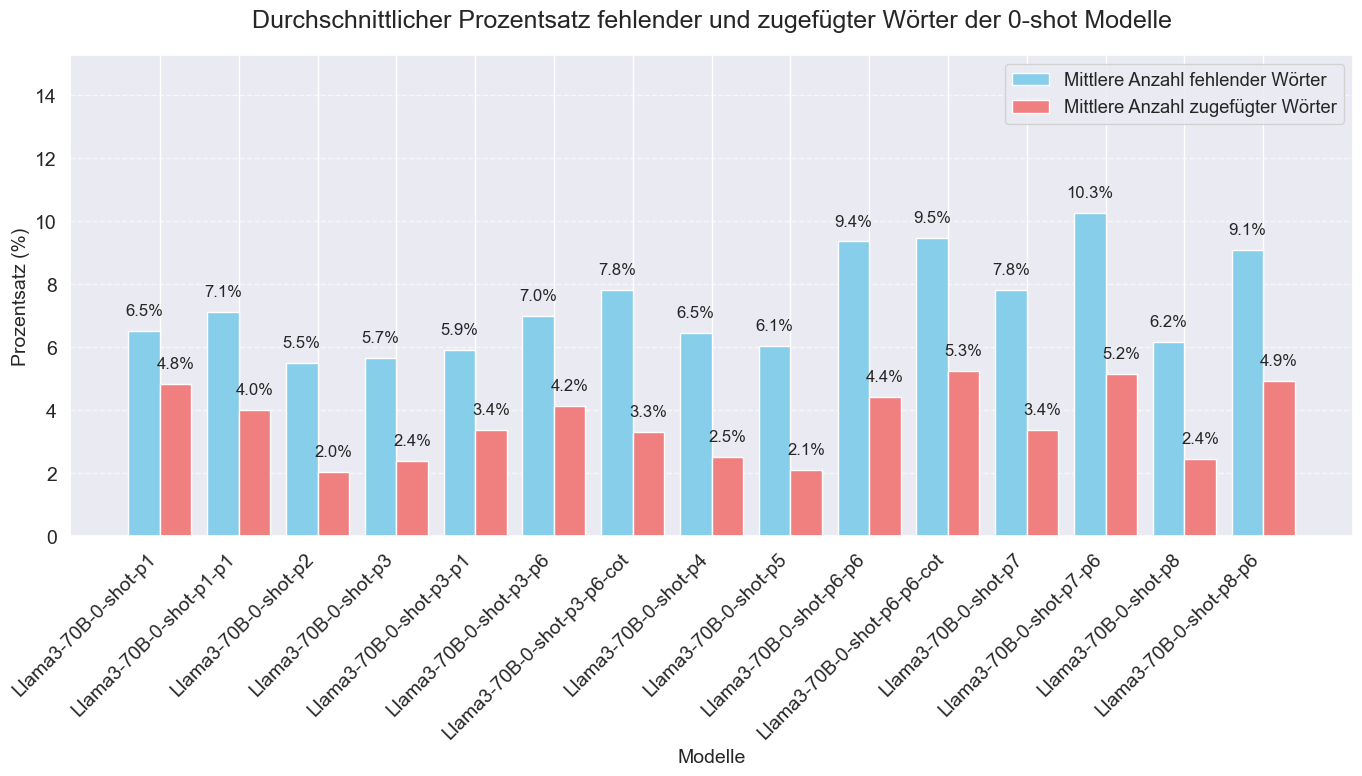

In [13]:
plot_avg_pct(all_metrics)

In [7]:
def plot_avg_metrics(all_metrics):
    sota_metrics = {
        'SciBERT (SOTA)': {
            'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
        },
        'R-BERT + SciBERT': {
            'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
        }
    }
    metrics_to_plot = ['precision', 'recall', 'f1']
    model_names = ['SciBERT (SOTA)'] + list(all_metrics.keys())
    model_names = [name.replace('-Instruct', '') for name in model_names]
    model_names = [name.replace('_', '-') for name in model_names]
    model_names = [name.replace('Gradient', 'Grad') for name in model_names]
    model_names = [name.replace('Llama-3', 'Llama3') for name in model_names]
    model_names = [name.replace('prompt-', 'p') for name in model_names]
    #model_names = [name.replace('-0-shot', '') for name in model_names]

    avg_precisions = [sota_metrics['SciBERT (SOTA)']['average']['precision']]
    avg_recalls = [sota_metrics['SciBERT (SOTA)']['average']['recall']]
    avg_f1_scores = [sota_metrics['SciBERT (SOTA)']['average']['f1']]

    for model, metrics in all_metrics.items():
        avg_precisions.append(metrics['average']['precision'])
        avg_recalls.append(metrics['average']['recall'])
        avg_f1_scores.append(metrics['average']['f1'])

    x = np.arange(len(model_names) * 4)
    bar_width = 1.8  # Breitere Balken
    opacity = 0.8
    gap = 0.95 # Abstand zwischen den Balken
    model_gap = 1.0  # Abstand zwischen den Modellen

    plt.figure(figsize=(14, 10))  # Größere Figur
    sns.set(style='darkgrid', font_scale=1.2)
    sns.set_palette('deep')
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Bessere Farben
    for i in range(len(model_names)):
        plt.bar(x[i * 4], avg_precisions[i], bar_width - gap, alpha=opacity, label='Precision' if i == 0 else '', color=colors[0])
        plt.bar(x[i * 4 + 1], avg_recalls[i], bar_width - gap, alpha=opacity, label='Recall' if i == 0 else '', color=colors[1])
        plt.bar(x[i * 4 + 2], avg_f1_scores[i], bar_width - gap, alpha=opacity, label='F1 Score' if i == 0 else '', color=colors[2])

    plt.xlabel('Modelle', fontsize=14)
    plt.ylabel('Score (%)', fontsize=14)
    plt.title(f'Durchschnittliche Metriken für AND, OR, NOT Operatoren der {versuch_name}', fontsize=18, pad=20)

    # Finde den Index des Modells mit dem höchsten F1-Score (ausgenommen SciBERT (SOTA) und Naive greedy match)
    max_f1_index = avg_f1_scores[1::].index(max(avg_f1_scores[1::])) + 1

    # Erstelle eine Liste von Formatierungen für die x-Tick-Labels
    tick_labels = [f'${{\\bf {name}}}$' if i == max_f1_index else name for i, name in enumerate(model_names)]

    plt.xticks(x[1::4], tick_labels, rotation=40, ha='right', fontsize=13)
    plt.ylim(0, 100)
    plt.yticks(fontsize=14)  # Größere Zahlen an der y-Achse
    plt.legend(title='Metriken', fontsize=12)
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.7)

    y_offset = 2  # Abstand zwischen Balken und Prozentzahlen
    for i in range(len(model_names)):
        plt.text(x[i * 4], avg_precisions[i] + y_offset, f'{avg_precisions[i]:.1f}%', ha='center', fontsize=10)
        plt.text(x[i * 4 + 1], avg_recalls[i] + y_offset, f'{avg_recalls[i]:.1f}%', ha='center', fontsize=10)
        plt.text(x[i * 4 + 2], avg_f1_scores[i] + y_offset, f'{avg_f1_scores[i]:.1f}%', ha='center', fontsize=10)

    plt.tight_layout()
    plt.savefig(f'pics/all_operators_{versuch_name}.png')
    plt.show()

### Durchschnittliche Performance über alle Operatoren [AND, OR, NOT] 

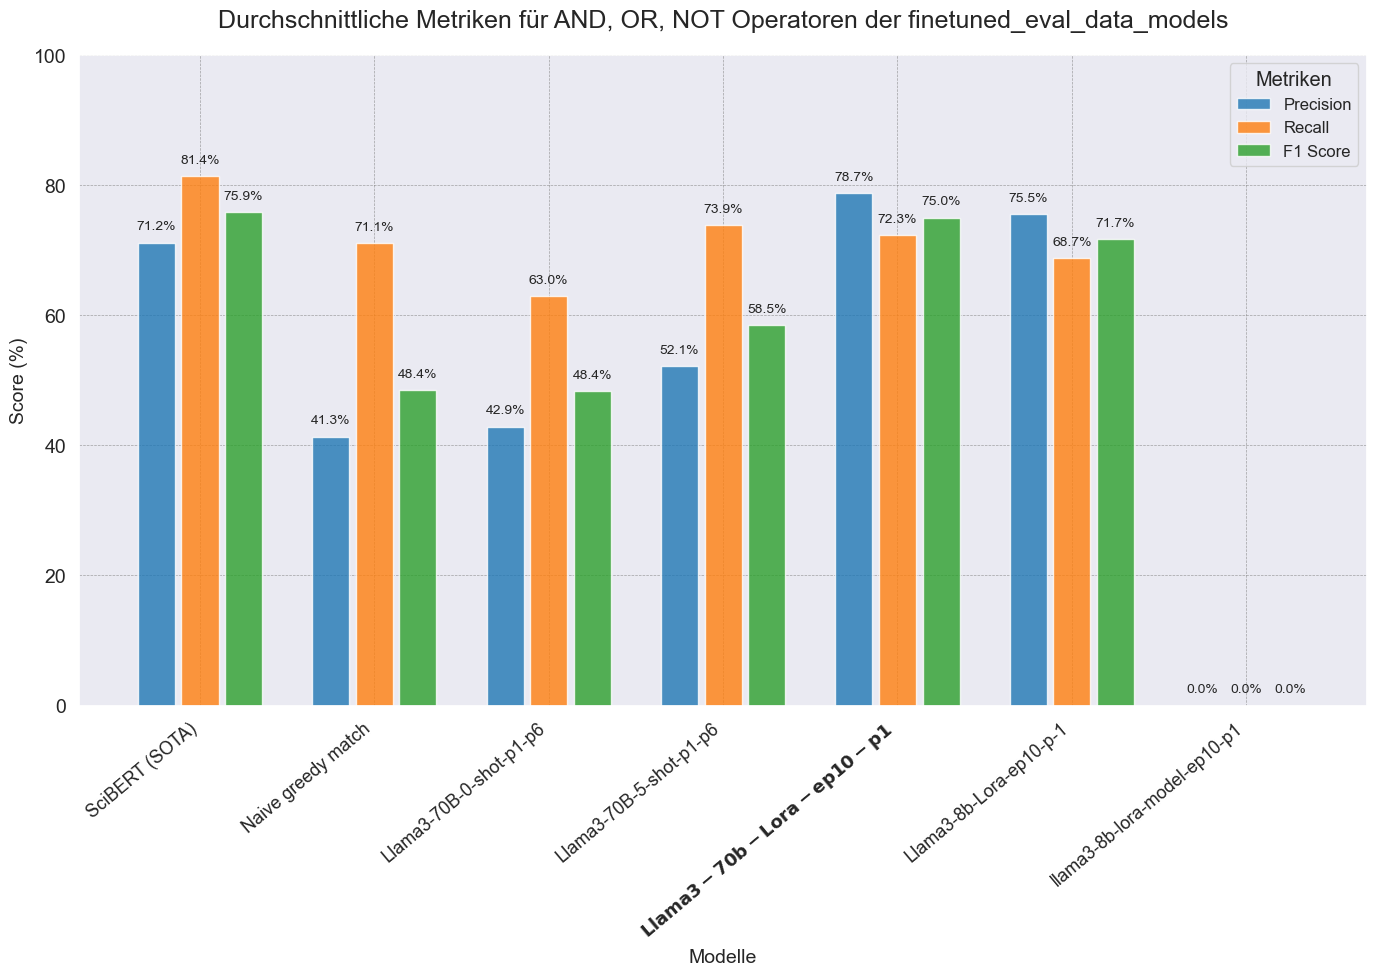

In [8]:
plot_avg_metrics(all_metrics)

### Perfomance der einzelnen Operatoren

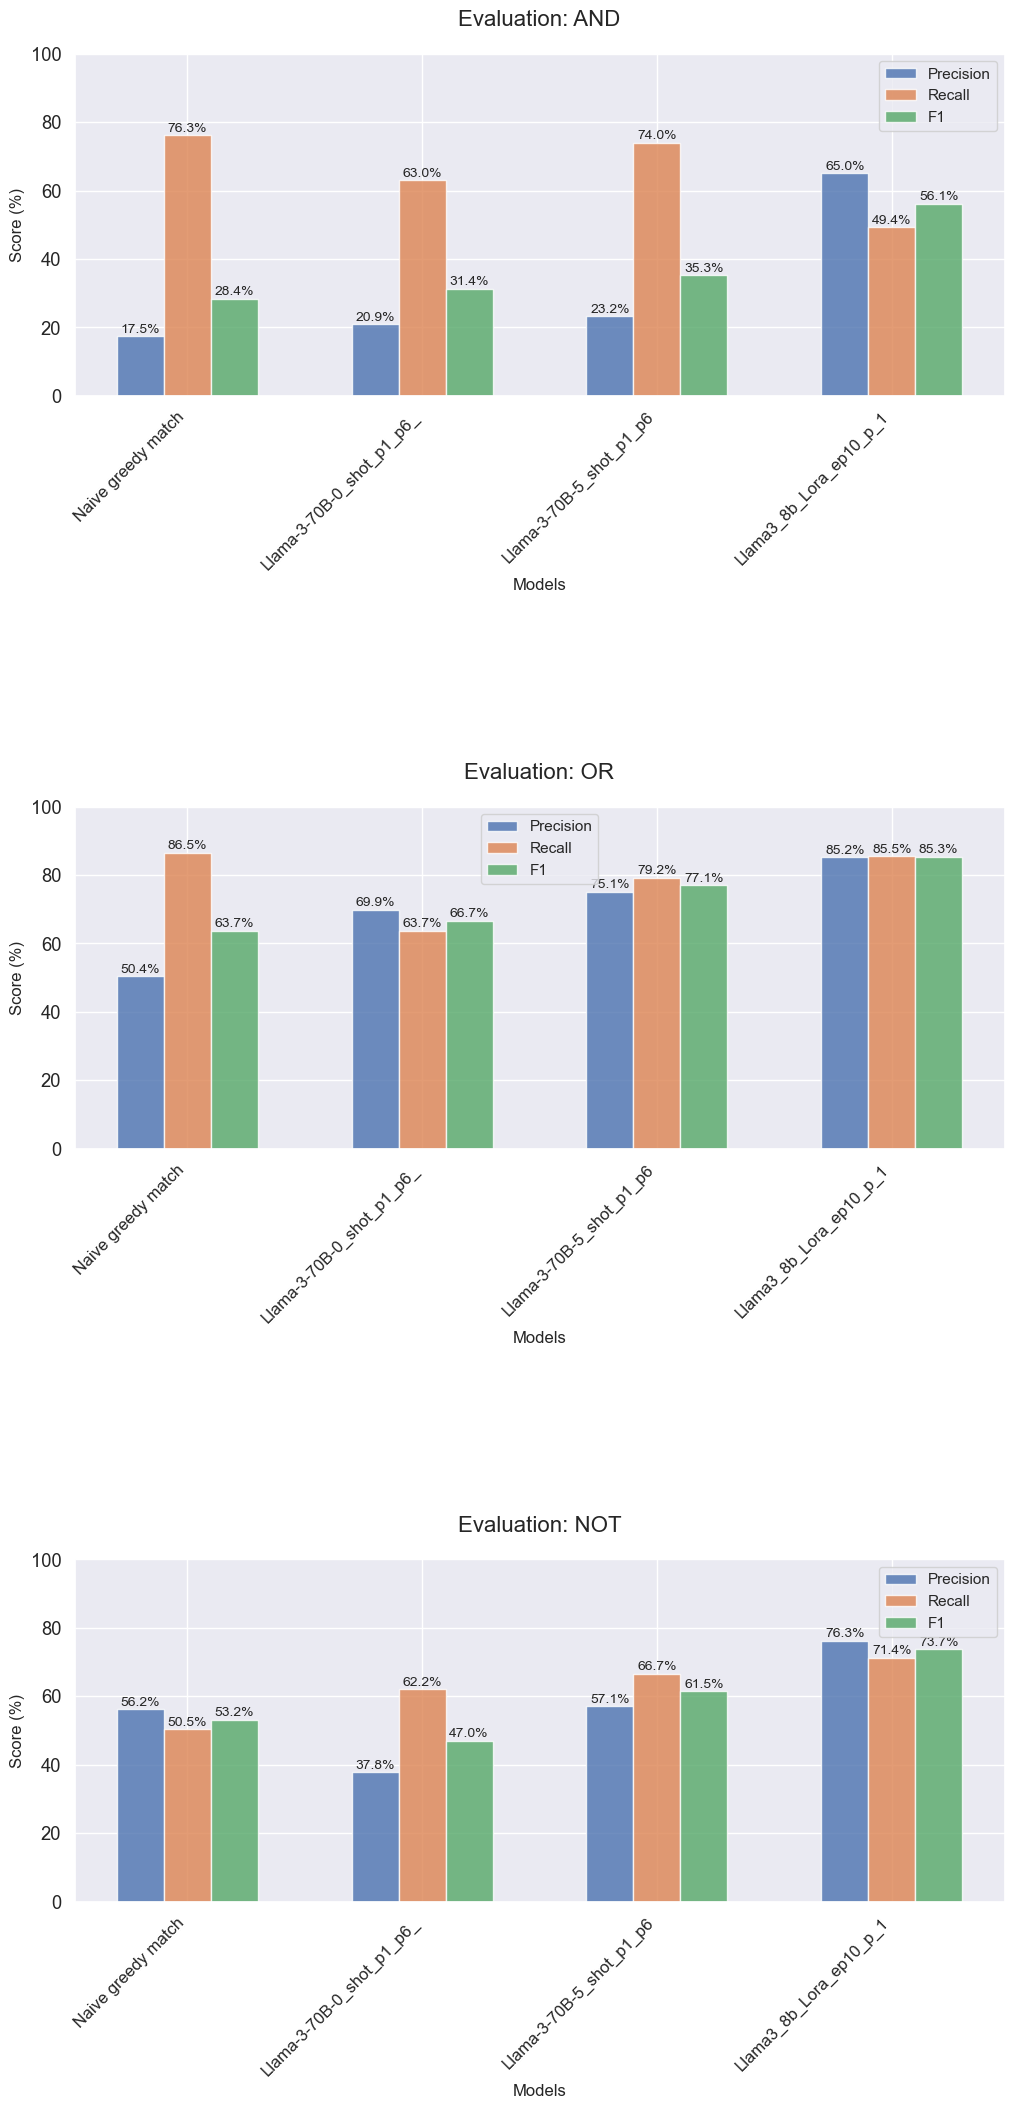

In [10]:
# 1 Instruct
# 2 Instruct +  5 Beispiele
# 3 
# 7 
# 9 
# 10 
plot_metrics(all_metrics)

### Plot Anzahl Operators

In [31]:
def plot_count_comparison(all_metrics):
    operators = ['AND', 'OR', 'NOT']
    count_metrics = ['total_label', 'total_model']
    fig, ax = plt.subplots(figsize=(16, 8))
    x = np.arange(len(operators))

    label_counts = [all_metrics[next(iter(all_metrics))][op]['total_label'] for op in operators]
    bar_width = 0.16
    opacity = 0.8

    colors = sns.color_palette("husl", len(all_metrics) + 1)

    ax.bar(x, label_counts, bar_width, alpha=opacity, color=colors[0], label='Label Count')
    for i, model in enumerate(all_metrics.keys()):
        count_values = [all_metrics[model][op]['total_model'] for op in operators]
        model_name = model.replace('Instruct', '').replace('_', ' ')
        ax.bar(x + (i + 1) * bar_width, count_values, bar_width, alpha=opacity, color=colors[i + 1], label=model_name)

        for j, v in enumerate(count_values):
            label_count = label_counts[j]
            diff_percent = ((v - label_count) / label_count) * 100
            color = 'darkgreen' if diff_percent >= 0 else 'red'
            ax.text(x[j] + (i + 1) * bar_width, v / 2, f'{diff_percent:+.0f}%', ha='center', va='center', fontsize=10, color=color, fontweight='bold')
            ax.text(x[j] + (i + 1) * bar_width, v + 100, str(v), ha='center', fontsize=11)

    for i, v in enumerate(label_counts):
        ax.text(x[i], v + 100, str(v), ha='center', fontsize=10)

    ax.set_xticks(x + bar_width * len(all_metrics) / 2)
    ax.set_xticklabels([f'{op}' for op in operators], fontsize=12)
    ax.set_xlabel('Operators', fontsize=12)
    ax.set_ylabel('Anzahl', fontsize=12)
    ax.set_title('Count Comparison: Labels vs Models per Operator', fontsize=16, pad=30)
    ax.legend(fontsize=11)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

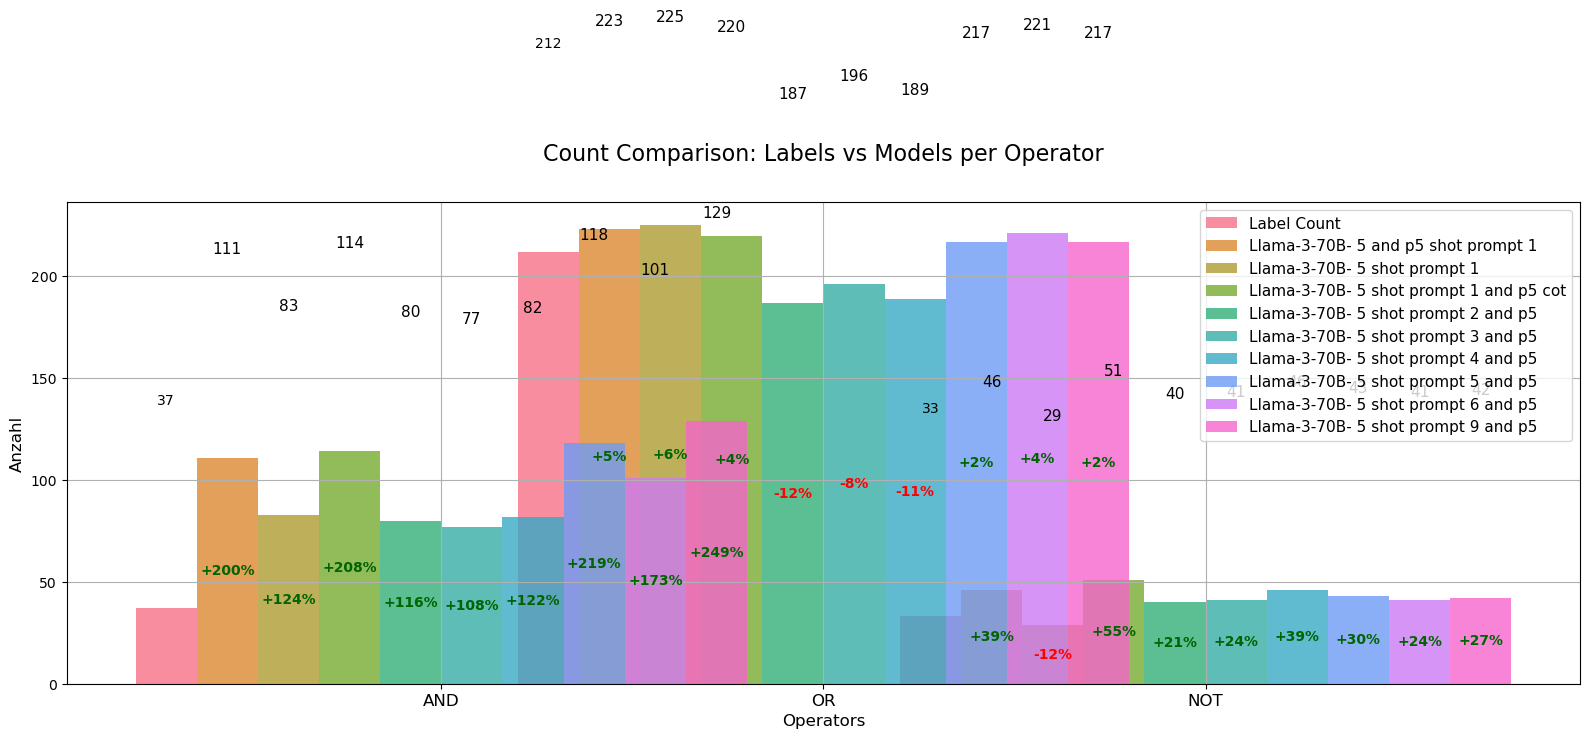

In [32]:
plot_count_comparison(all_metrics)

### Evaluiere n-shot Modelle

## Model vs SOTA


In [38]:
print(models)

model_to_plot = models[len(models)-1] # len(models)-1
model_name = model_to_plot
model_to_plot

['Llama-3-70B-Instruct_5_and_p5_shot_prompt_1', 'Llama-3-70B-Instruct_5_shot_prompt_1', 'Llama-3-70B-Instruct_5_shot_prompt_1_and_p5_cot', 'Llama-3-70B-Instruct_5_shot_prompt_2_and_p5', 'Llama-3-70B-Instruct_5_shot_prompt_3_and_p5', 'Llama-3-70B-Instruct_5_shot_prompt_4_and_p5', 'Llama-3-70B-Instruct_5_shot_prompt_5_and_p5', 'Llama-3-70B-Instruct_5_shot_prompt_6_and_p5', 'Llama-3-70B-Instruct_5_shot_prompt_9_and_p5']


'Llama-3-70B-Instruct_5_shot_prompt_9_and_p5'

In [39]:
all_metrics

{'Llama-3-70B-Instruct_5_and_p5_shot_prompt_1': {'AND': {'precision': 19.81981981981982,
   'recall': 59.45945945945946,
   'f1': 29.72972972972973,
   'accuracy': 59.45945945945946,
   'total_label': 37,
   'total_model': 111,
   'correct_count': 22,
   'low_tp_ncts': []},
  'OR': {'precision': 72.39819004524887,
   'recall': 75.47169811320755,
   'f1': 73.90300230946883,
   'accuracy': 75.47169811320755,
   'total_label': 212,
   'total_model': 223,
   'correct_count': 160,
   'low_tp_ncts': []},
  'NOT': {'precision': 42.22222222222222,
   'recall': 57.57575757575758,
   'f1': 48.71794871794872,
   'accuracy': 57.57575757575758,
   'total_label': 33,
   'total_model': 46,
   'correct_count': 19,
   'low_tp_ncts': []},
  'average_missing_percentage': 4.071659632367738,
  'average': {'precision': 44.81341069576364,
   'recall': 64.16897171614153,
   'f1': 50.78356025238242,
   'accuracy': 64.16897171614153}},
 'Llama-3-70B-Instruct_5_shot_prompt_1': {'AND': {'precision': 21.9512195121

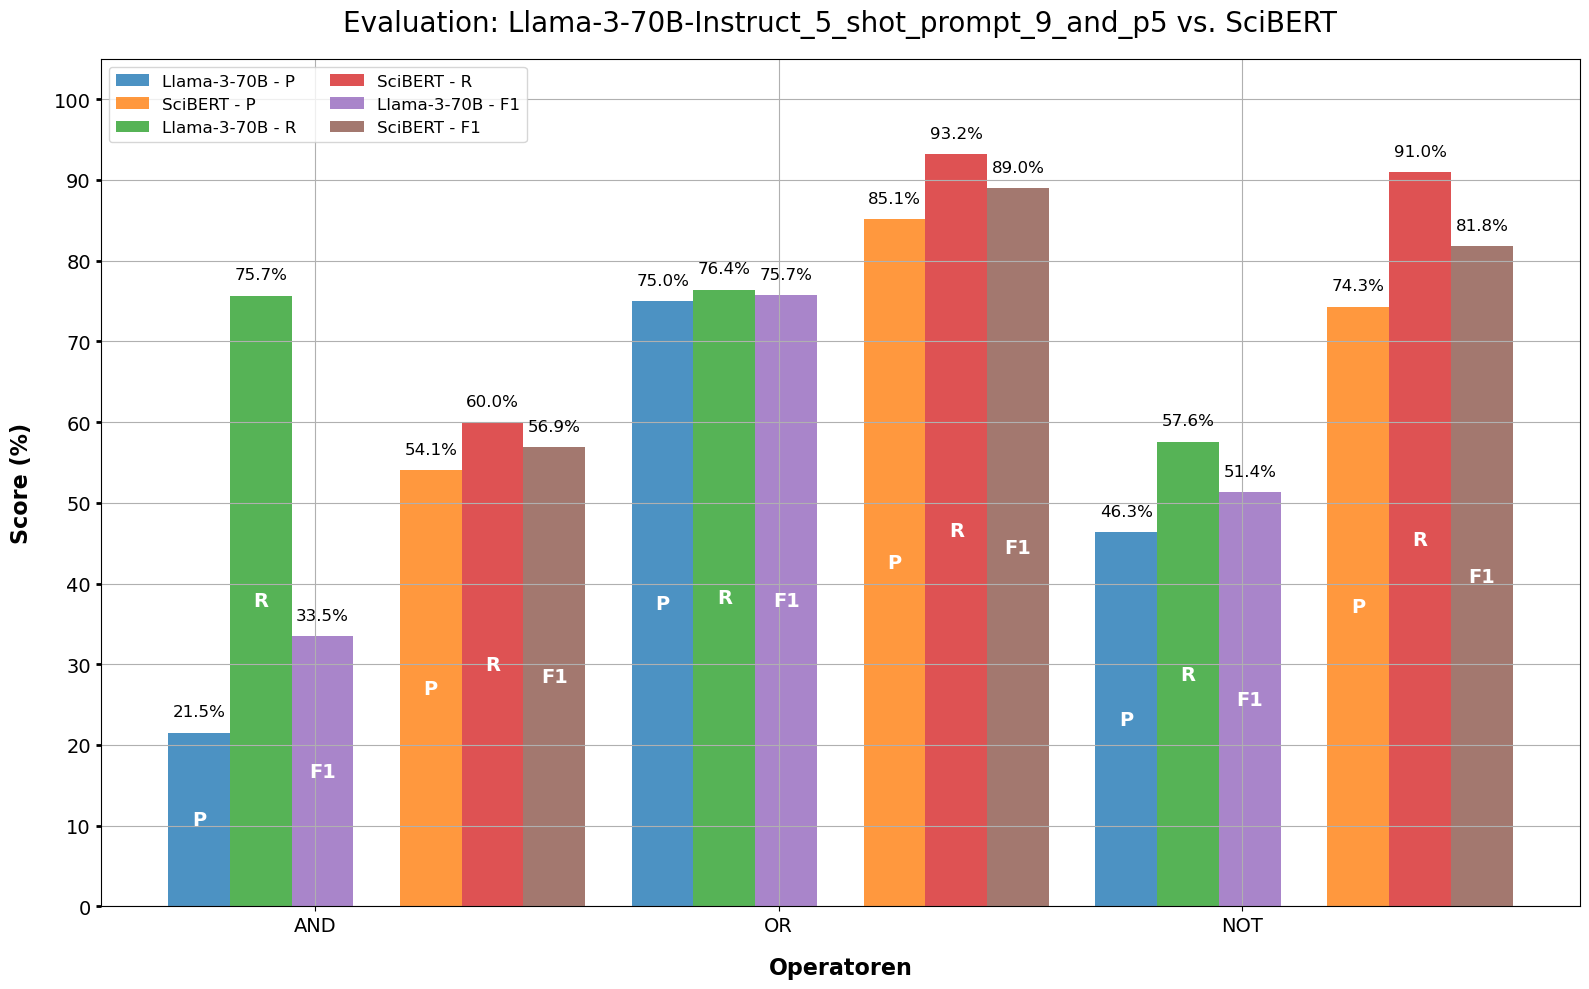

In [40]:
model_metrics = all_metrics[model_to_plot]


sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0},
        'average': {'precision': 71.16, 'recall': 81.39, 'f1': 75.89}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2},
        'average': {'precision': 72.23, 'recall': 78.23, 'f1': 75.0}
    }
}

operators = ['AND', 'OR', 'NOT']
metrics_to_plot = ['precision', 'recall', 'f1']
metric_labels = {'precision': 'P', 'recall': 'R', 'f1': 'F1'}

fig, ax = plt.subplots(figsize=(16, 10))

x = np.arange(len(operators))
bar_width = 0.4
opacity = 0.8
gap = 0.1

for i, metric in enumerate(metrics_to_plot):
    model_values = [model_metrics[op][metric] for op in operators]
    sota_values = [sota_metrics['SciBERT'][op][metric] for op in operators]

    ax.bar(x - bar_width/2 - gap/2 + i*bar_width/3, model_values, bar_width/3, alpha=opacity, label=f'{model_name.split("-Instruct")[0]} - {metric_labels[metric]}')
    ax.bar(x + bar_width/2 + gap/2 + i*bar_width/3, sota_values, bar_width/3, alpha=opacity, label=f'SciBERT - {metric_labels[metric]}')

    for j, (model_value, sota_value) in enumerate(zip(model_values, sota_values)):
        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value/2, f'{metric_labels[metric]}', ha='center', va='center', fontsize=14, fontweight='bold', color='white')

        ax.text(j - bar_width/2 - gap/2 + i*bar_width/3, model_value + 2, f'{model_value:.1f}%', ha='center', fontsize=12)
        ax.text(j + bar_width/2 + gap/2 + i*bar_width/3, sota_value + 2, f'{sota_value:.1f}%', ha='center', fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(operators, fontsize=14)
ax.set_xlabel('Operatoren', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylabel('Score (%)', fontsize=16, fontweight='bold', labelpad=15)
ax.set_ylim(0, 105)
ax.set_yticks(np.arange(0, 101, 10))
ax.tick_params(axis='y', labelsize=14, width=2)
ax.yaxis.set_tick_params(labelsize=14)
ax.set_title(f'Evaluation: {model_name} vs. SciBERT', fontsize=20, pad=20)
ax.legend(fontsize=12, ncol=2, loc='upper left')
ax.grid(True)

plt.tight_layout()
plt.savefig(f"pics/{model_to_plot}_vs_sota__{versuch_ordner}.png")
plt.show()

In [36]:
def generate_latex_table(all_metrics, operators, metrics_to_plot):
    latex_table = "\\begin{table}[h]\n"
    latex_table += "\\centering\n"
    latex_table += "\\begin{tabular}{l" + "c" * (len(metrics_to_plot) * len(operators)) + "}\n"
    latex_table += "\\toprule\n"
    latex_table += "Model & " + " & ".join([f"\\multicolumn{{{len(metrics_to_plot)}}}{{c}}{{{op}}}" for op in operators]) + " \\\\\n"
    latex_table += "\\cmidrule(lr){2-" + str(len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(len(metrics_to_plot) + 2) + "-" + str(2 * len(metrics_to_plot) + 1) + "} " + " \\cmidrule(lr){" + str(2 * len(metrics_to_plot) + 2) + "-" + str(3 * len(metrics_to_plot) + 1) + "}\n"
    latex_table += " & " + " & ".join([" & ".join(metric[:1].upper() for metric in metrics_to_plot) for _ in operators]) + " \\\\\n"
    latex_table += "\\midrule\n"

    for model, model_metrics in all_metrics.items():
        row = model.replace("_", "-")  # Replace underscores with hyphens in the model name
        for op in operators:
            for metric in metrics_to_plot:
                row += " & {:.2f}".format(model_metrics[op][metric])
        row += " \\\\\n"
        latex_table += row

    latex_table += "\\bottomrule\n"
    latex_table += "\\end{tabular}\n"
    latex_table += "\\caption{Model Performance Metrics}\n"
    latex_table += "\\label{tab:model_metrics}\n"
    latex_table += "\\end{table}\n"

    os.makedirs("latex", exist_ok=True)
    with open("latex/model_metrics_table.tex", "w") as file:
        file.write(latex_table)
    return latex_table

# Generate LaTeX table
#latex_table = generate_latex_table(all_metrics, operators, metrics_to_plot)

#print(latex_table)

In [37]:
sota_metrics = {
    'SciBERT': {
        'AND': {'precision': 54.1, 'recall': 60.0, 'f1': 56.9},
        'NOT': {'precision': 74.3, 'recall': 91.0, 'f1': 81.8},
        'OR': {'precision': 85.1, 'recall': 93.2, 'f1': 89.0}
    },
    'R-BERT + SciBERT': {
        'AND': {'precision': 53.8, 'recall': 53.8, 'f1': 53.8},
        'NOT': {'precision': 74.5, 'recall': 88.7, 'f1': 81.0},
        'OR': {'precision': 88.4, 'recall': 92.2, 'f1': 90.2}
    }
}

def calculate_average_metrics(metrics):
    avg_metrics = {'precision': 0, 'recall': 0, 'f1': 0}
    operators = ['AND', 'NOT', 'OR']

    for metric in avg_metrics.keys():
        avg_metrics[metric] = sum(metrics[op][metric] for op in operators) / len(operators)

    return avg_metrics

for model, metrics in sota_metrics.items():
    avg_metrics = calculate_average_metrics(metrics)
    print(f"Average metrics for {model}: {avg_metrics}")

Average metrics for SciBERT: {'precision': 71.16666666666667, 'recall': 81.39999999999999, 'f1': 75.89999999999999}
Average metrics for R-BERT + SciBERT: {'precision': 72.23333333333333, 'recall': 78.23333333333333, 'f1': 75.0}
